Import Library

In [19]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

Load Dataset

In [2]:
df = pd.read_csv("../dataset_raw/apple_quality.csv")

df.head()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good


Informasi Dataset

In [3]:
print(df.shape)

df.info()

(4001, 9)
<class 'pandas.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   A_id         4000 non-null   float64
 1   Size         4000 non-null   float64
 2   Weight       4000 non-null   float64
 3   Sweetness    4000 non-null   float64
 4   Crunchiness  4000 non-null   float64
 5   Juiciness    4000 non-null   float64
 6   Ripeness     4000 non-null   float64
 7   Acidity      4001 non-null   str    
 8   Quality      4000 non-null   str    
dtypes: float64(7), str(2)
memory usage: 281.4 KB


Missing Value

In [5]:
df.isnull().sum()

A_id           1
Size           1
Weight         1
Sweetness      1
Crunchiness    1
Juiciness      1
Ripeness       1
Acidity        0
Quality        1
dtype: int64

Data Duplikat

In [6]:
df.duplicated().sum()

np.int64(0)

Statistik Deskriptif

In [7]:
df.describe()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,1999.500000,-0.503015,-0.989547,-0.470479,0.985478,0.512118,0.498277
std,1154.844867,1.928059,1.602507,1.943441,1.402757,1.930286,1.874427
min,0.000000,-7.151703,-7.149848,-6.894485,-6.055058,-5.961897,-5.864599
25%,999.750000,-1.816765,-2.011770,-1.738425,0.062764,-0.801286,-0.771677
50%,1999.500000,-0.513703,-0.984736,-0.504758,0.998249,0.534219,0.503445
75%,2999.250000,0.805526,0.030976,0.801922,1.894234,1.835976,1.766212
max,3999.000000,6.406367,5.790714,6.374916,7.619852,7.364403,7.237837


Distribusi Target

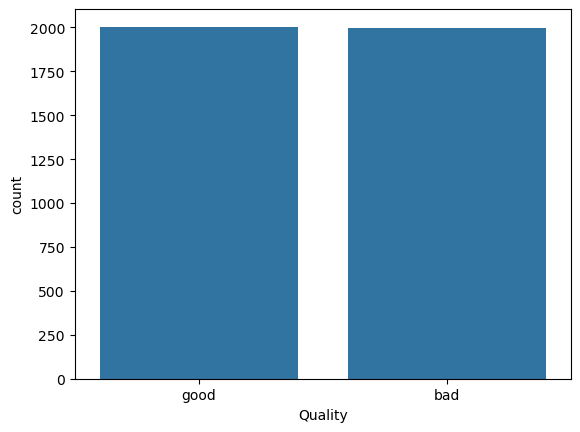

In [9]:
sns.countplot(
    data=df,
    x="Quality"
)

plt.show()

Histogram

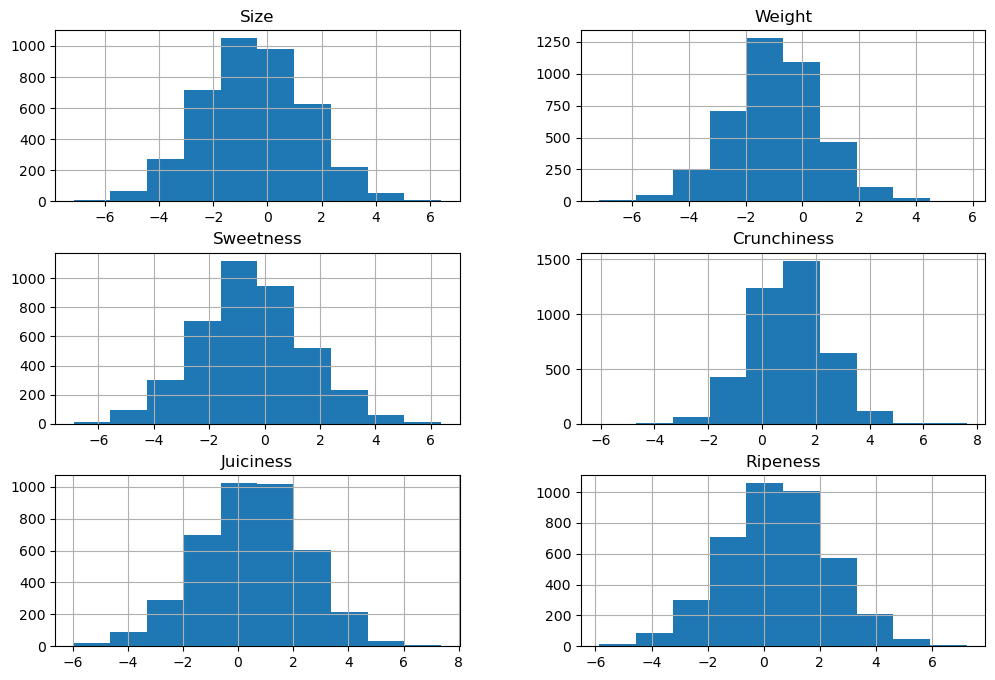

In [10]:
numerical_columns = [
    "Size",
    "Weight",
    "Sweetness",
    "Crunchiness",
    "Juiciness",
    "Ripeness"
]

df[numerical_columns].hist(
    figsize=(12,8)
)

plt.show()

Correlation Matrix

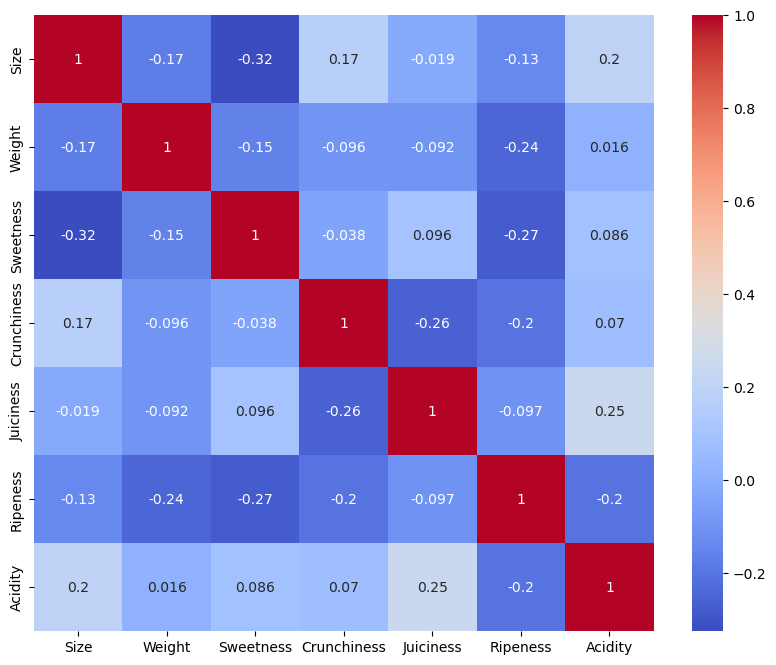

In [12]:
temp_df = df.copy()

temp_df["Acidity"] = pd.to_numeric(
    temp_df["Acidity"],
    errors="coerce"
)

temp_df = temp_df.drop(
    columns=["A_id"]
)

plt.figure(figsize=(10,8))

sns.heatmap(
    temp_df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Preprocessing Manual

In [13]:
df["Acidity"] = pd.to_numeric(
    df["Acidity"],
    errors="coerce"
)

df.dropna(inplace=True)


df.drop(
    columns=["A_id"],
    inplace=True
)

df.drop_duplicates(inplace=True)

encoder = LabelEncoder()

df["Quality"] = encoder.fit_transform(
    df["Quality"]
)

df.head()

,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590,1
1,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809,1
2,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636,0
3,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723,1
4,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984,1


Train Test Split

In [14]:
X = df.drop(
    'Quality',
    axis=1
)

y = df['Quality']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

Train : (3200, 7)
Test  : (800, 7)


In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [17]:
train_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

train_df['Quality'] = (
    y_train.reset_index(drop=True)
)

test_df = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

test_df['Quality'] = (
    y_test.reset_index(drop=True)
)

Save Dataset

In [20]:
output_folder = "dataset_preprocessing"

os.makedirs(
    output_folder,
    exist_ok=True
)

In [21]:
train_df.to_csv(
    f"{output_folder}/train.csv",
    index=False
)

test_df.to_csv(
    f"{output_folder}/test.csv",
    index=False
)